Task 1: Dataset Understanding
Shape: (2000, 17)

Data Types:
 customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Target Value Counts:
 churn
0    1969
1      31
Name: count, dtype: int64

Missing Values:
 customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method 

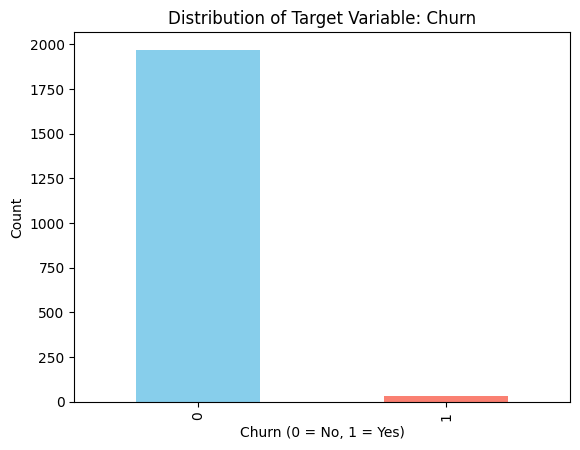

In [6]:
print ("Task 1: Dataset Understanding")

#importing necessary libraries and loading dataset
import pandas as pd
df = pd.read_csv('customer_churn_nn.csv')

# Shape of dataset (defining number of rows, columns)
print("Shape:", df.shape)

# Type of input features (Data types of each column)
print("\nData Types:\n", df.dtypes)

# Target variable description (assuming 'churn' is the target)
print("\nTarget Value Counts:\n", df['churn'].value_counts())

# Missing value check
print("\nMissing Values:\n", df.isnull().sum())

# Basic statistical summary
print("\nStatistical Summary:\n", df.describe())

# Distribution of target variable
import matplotlib.pyplot as plt
df['churn'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title("Distribution of Target Variable: Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [7]:
print ("Task 2: Data Preprocessing")

# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Step 2: Load dataset
df = pd.read_csv("customer_churn_nn.csv")

# Step 3: Handle missing values
# Fill numeric columns with median, categorical with mode
for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Step 4: Separate features and target
X = df.drop("churn", axis=1)
y = df["churn"]

# Step 5: Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_cols = X.select_dtypes(include=['float64','int64']).columns.tolist()

# Step 6: Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ])

# Step 7: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 8: Fit preprocessor on training data and transform both sets
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Task 2: Data Preprocessing
Training set shape: (1600, 1628)
Testing set shape: (400, 1628)


In [9]:
print ("Task 3: Neural Network Model Building")

# Step 1: Import libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input # Import Input layer

# Step 2: Build the model
model = Sequential([
    # Input layer: Use Input(shape) as the first layer
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),

    # Hidden layer: 8 neurons, ReLU activation
    Dense(8, activation='relu'),

    # Output layer: 1 neuron, sigmoid activation (binary classification)
    Dense(1, activation='sigmoid')
])

# Step 3: Compile the model
model.compile(
    optimizer='adam',              # Optimization algorithm
    loss='binary_crossentropy',    # Loss function for binary target
    metrics=['accuracy']           # Track accuracy during training
)

# Step 4: Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,                     # Number of passes through dataset
    batch_size=32,                 # Samples per gradient update
    verbose=1
)

# Step 5: Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_acc)

Task 3: Neural Network Model Building
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9569 - loss: 0.5472 - val_accuracy: 0.9850 - val_loss: 0.3744
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9844 - loss: 0.2328 - val_accuracy: 0.9850 - val_loss: 0.1249
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9844 - loss: 0.0959 - val_accuracy: 0.9850 - val_loss: 0.0759
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9844 - loss: 0.0745 - val_accuracy: 0.9850 - val_loss: 0.0673
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9844 - loss: 0.0690 - val_accuracy: 0.9850 - val_loss: 0.0634
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9844 - loss: 0.0657 - val_accuracy: 0.9850 - val_loss: 0.0603
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9844 - loss: 0.0627 - val_accuracy: 0.9850 - val_loss: 0.0592
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9844 - loss: 0

Task 4: Training and Evaluation
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9881 - loss: 0.0276 - val_accuracy: 0.9875 - val_loss: 0.0529
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9912 - loss: 0.0250 - val_accuracy: 0.9875 - val_loss: 0.0561
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9931 - loss: 0.0222 - val_accuracy: 0.9875 - val_loss: 0.0567
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9944 - loss: 0.0202 - val_accuracy: 0.9850 - val_loss: 0.0592
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9950 - loss: 0.0183 - val_accuracy: 0.9875 - val_loss: 0.0603
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9950 - loss: 0.0161 - val_accuracy: 0.9850 - val_loss: 0.0615
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9950 - loss: 0.0144 - val_accuracy: 0.9850 - val_loss: 0.0646
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9950 - loss: 0.0128

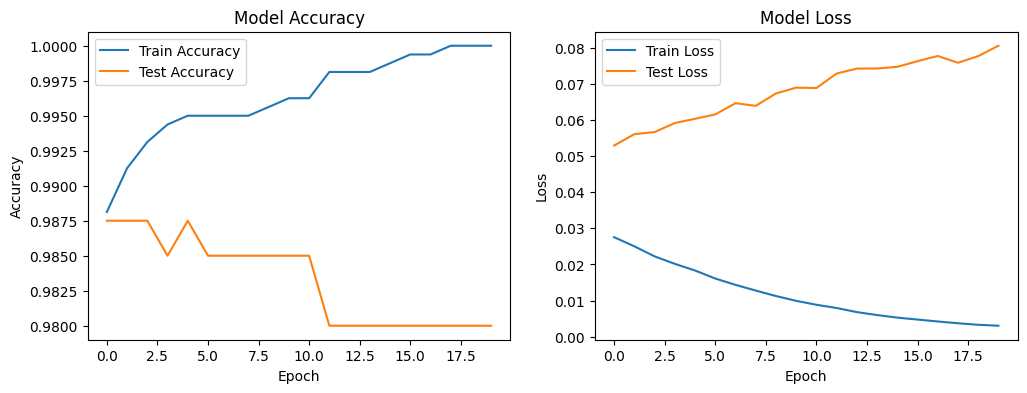

Test Accuracy: 0.9800000190734863
Test Loss: 0.08055035769939423
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


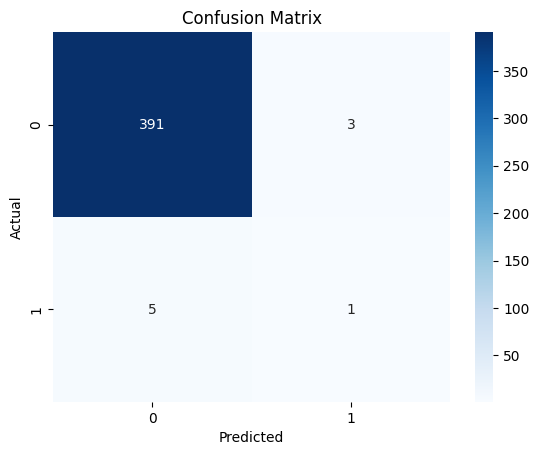


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       394
           1       0.25      0.17      0.20         6

    accuracy                           0.98       400
   macro avg       0.62      0.58      0.59       400
weighted avg       0.98      0.98      0.98       400



In [10]:
print ("Task 4: Training and Evaluation")
# Step 1: Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

# Step 2: Plot training accuracy and loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Step 3: Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

# Step 4: Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = (model.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Task 5: Hyperparameter Experimentation
Experiment 1 - More Hidden Layers
Experiment 2 - Different Learning Rate
Experiment 3 - Larger Batch Size
Model 1 (More Hidden Layers) - Test Accuracy: 0.9800, Test Loss: 0.0599
Model 2 (Different Learning Rate) - Test Accuracy: 0.9850, Test Loss: 0.0531
Model 3 (Larger Batch Size) - Test Accuracy: 0.9850, Test Loss: 0.0540


,Model,Test Accuracy,Test Loss
0,Original Model (from Task 4),0.980,0.080550
1,Model 1 (More Hidden Layers),0.980,0.059864
2,Model 2 (Different Learning Rate),0.985,0.053094
3,Model 3 (Larger Batch Size),0.985,0.054015


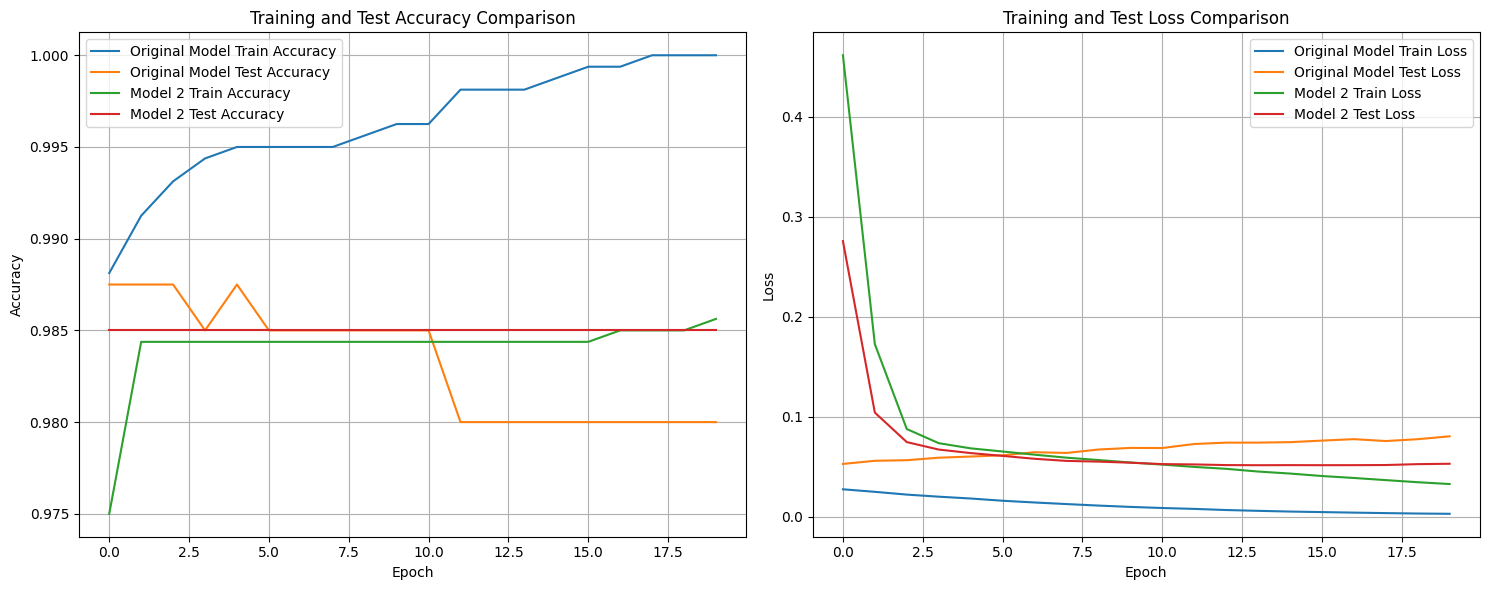

In [16]:
print ("Task 5: Hyperparameter Experimentation")

# Import Input layer if not already imported
from tensorflow.keras.layers import Input

print ("Experiment 1 - More Hidden Layers")

model1 = Sequential([
    Input(shape=(X_train.shape[1],)), # Use Input layer
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history1 = model1.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=32, verbose=0)

print ("Experiment 2 - Different Learning Rate")
from tensorflow.keras.optimizers import Adam

model2 = Sequential([
    Input(shape=(X_train.shape[1],)), # Use Input layer
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model2.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
history2 = model2.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=32, verbose=0)

print ("Experiment 3 - Larger Batch Size")

model3 = Sequential([
    Input(shape=(X_train.shape[1],)), # Use Input layer
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history3 = model3.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=64, verbose=0)

# Evaluate model1 (More Hidden Layers)
loss1, accuracy1 = model1.evaluate(X_test, y_test, verbose=0)
print(f"Model 1 (More Hidden Layers) - Test Accuracy: {accuracy1:.4f}, Test Loss: {loss1:.4f}")

# Evaluate model2 (Different Learning Rate)
loss2, accuracy2 = model2.evaluate(X_test, y_test, verbose=0)
print(f"Model 2 (Different Learning Rate) - Test Accuracy: {accuracy2:.4f}, Test Loss: {loss2:.4f}")

# Evaluate model3 (Larger Batch Size)
loss3, accuracy3 = model3.evaluate(X_test, y_test, verbose=0)
print(f"Model 3 (Larger Batch Size) - Test Accuracy: {accuracy3:.4f}, Test Loss: {loss3:.4f}")

# For better visual comparison, let's also put them in a DataFrame
import pandas as pd
comparison_data = {
    'Model': ['Original Model (from Task 4)', 'Model 1 (More Hidden Layers)', 'Model 2 (Different Learning Rate)', 'Model 3 (Larger Batch Size)'],
    'Test Accuracy': [test_acc, accuracy1, accuracy2, accuracy3],
    'Test Loss': [test_loss, loss1, loss2, loss3]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# Plotting Training & Validation Accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history.history['accuracy'], label='Original Model Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Original Model Test Accuracy')
plt.plot(history2.history['accuracy'], label='Model 2 Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Model 2 Test Accuracy')
plt.title('Training and Test Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plotting Training & Validation Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history.history['loss'], label='Original Model Train Loss')
plt.plot(history.history['val_loss'], label='Original Model Test Loss')
plt.plot(history2.history['loss'], label='Model 2 Train Loss')
plt.plot(history2.history['val_loss'], label='Model 2 Test Loss')
plt.title('Training and Test Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()